# Contrast Maximization Optical Flow on DSEC (thun_00_a)

Model-based optical flow via contrast maximization (Gallego, Rebecq, Scaramuzza, CVPR 2018), run on one DSEC training sequence and evaluated against DSEC-Flow ground truth.

Setup used here: one 100 ms window, constant flow per patch, variance as the contrast objective, coarse-to-fine grid search.

## 1. Setup and data download

`hdf5plugin` (installed as an `evcam` dependency and imported by `evcam/io.py`) is needed because DSEC event files are Blosc/ZSTD compressed; h5py can't read them without it. The download (`scripts/download_data.py`, which skips files already in `data/dsec/thun_00_a/`) pulls only the left event camera (~300 MB) plus forward flow ground truth (~12 MB) for thun_00_a, which is one of the smaller sequences with flow GT.

In [1]:
import sys, os
if "google.colab" in sys.modules:
    if not os.path.exists("event-perception"):
        # PLACEHOLDER: replace GITHUB_USER with the GitHub account that hosts this repo
        !git clone -q https://github.com/GITHUB_USER/event-perception.git
    %cd event-perception
    !pip install -q -e .
else:
    # local: assumes `pip install -e .` was run from the repo root
    os.chdir(os.path.dirname(os.path.abspath("")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from evcam.io import open_dsec_events, load_rectify_map, load_flow_timestamps, list_flow_files, load_flow, get_events
from evcam.cmax import iwe, contrast, patchwise_flow
from evcam.metrics import endpoint_error, epe, n_pixel_error
from evcam.viz import flow_to_rgb

SEQ = "thun_00_a"
DATA = f"data/dsec/{SEQ}"
!{sys.executable} scripts/download_data.py --sequence {SEQ}
print(os.listdir(DATA), os.listdir(f"{DATA}/events_left"))

DSEC thun_00_a -> data/dsec/thun_00_a
  have     thun_00_a_events_left.zip
  have     thun_00_a_optical_flow_forward_event.zip
  have     thun_00_a_optical_flow_forward_timestamps.txt
done: ['events_left', 'flow', 'thun_00_a_events_left.zip', 'thun_00_a_optical_flow_forward_event.zip', 'thun_00_a_optical_flow_forward_timestamps.txt']


['thun_00_a_optical_flow_forward_event.zip', 'thun_00_a_optical_flow_forward_timestamps.txt', 'events_left', 'thun_00_a_events_left.zip', 'flow'] ['rectify_map.h5', 'events.h5']


## 2. Loading events and ground truth

The loading functions used here (`open_dsec_events`, `load_rectify_map`, `load_flow`, `get_events`, ...) are in `evcam/io.py`.

Relevant DSEC format details:
- `events.h5` holds `x, y, t, p` (t in µs), a `t_offset` to convert to the global clock used by the flow timestamps, and `ms_to_idx`, a millisecond-to-index lookup so we can slice a time window without reading all ~134M events.
- Events are stored in raw (distorted) sensor coordinates, but GT flow is in the rectified left-camera frame, so events are mapped through `rectify_map.h5` first.
- GT flow is a 16-bit PNG per 100 ms window: R = x flow, G = y flow, B = valid mask, decoded as `(value - 2^15) / 128` pixels. It's the displacement from `t_k` to `t_k+1`, and it's sparse (LiDAR-based, static scene only).
- OpenCV loads channels as BGR, hence the `[..., ::-1]`. The sorted PNG files line up row by row with the timestamp file.

In [3]:
H, W = 480, 640
ev = open_dsec_events(f"{DATA}/events_left/events.h5")
rect_map = load_rectify_map(f"{DATA}/events_left/rectify_map.h5")   # (H, W, 2)

flow_ts = load_flow_timestamps(f"{DATA}/{SEQ}_optical_flow_forward_timestamps.txt")
flow_files = list_flow_files(f"{DATA}/flow")
print(f"{len(ev['events/t']):,} events, {len(flow_files)} GT flow maps")

134,133,270 events, 41 GT flow maps


## 3. One 100 ms window

Pick GT window `K` and pull the matching events. Time is normalized to [0, 1) so a flow `d` (in pixels per window) is directly comparable to the GT displacement.

Left: GT flow with the standard HSV encoding (hue = direction, brightness = magnitude). Right: where GT exists. The unwarped event image is shown in section 4 once the accumulation function is introduced.

window 10: 1,096,342 events, 18.4% of pixels have GT, median GT displacement 7.0 px


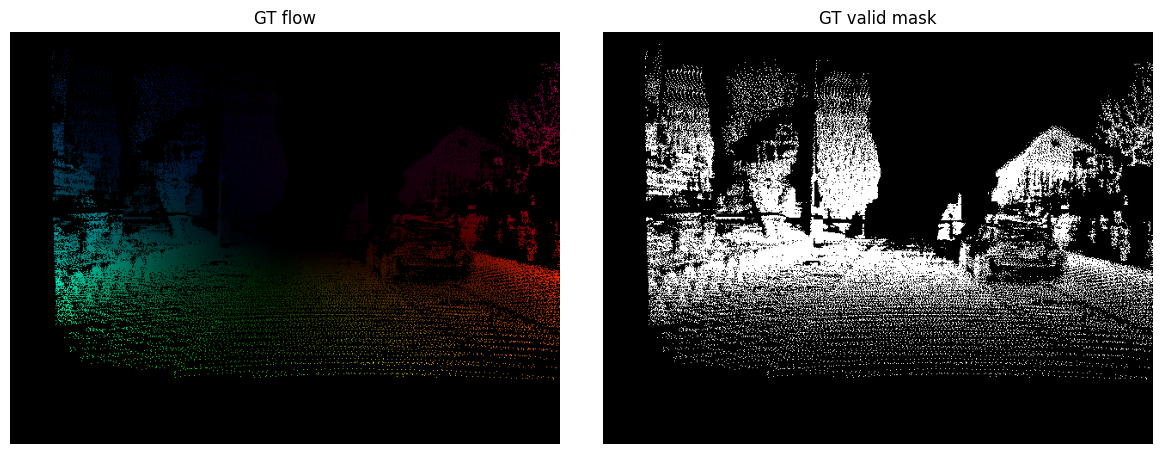

In [4]:
K = 10
t0, t1 = flow_ts[K]
x, y, tn, p = get_events(ev, rect_map, t0, t1)   # rectified x, y; time normalized to [0, 1); polarity
gt, valid = load_flow(flow_files[K])
print(f"window {K}: {len(x):,} events, {valid.mean():.1%} of pixels have GT, "
      f"median GT displacement {np.median(np.linalg.norm(gt[valid], axis=-1)):.1f} px")

counts = None  # filled in section 4 with iwe()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(flow_to_rgb(gt, valid)); ax[0].set_title("GT flow")
ax[1].imshow(valid, cmap="gray"); ax[1].set_title("GT valid mask")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 4. Image of Warped Events (IWE) and the contrast objective

Each event is moved back to the window start under a candidate flow `d`: `x' = x - d * t_norm`. Warped events are accumulated with bilinear voting (each event splits its weight over the 4 nearest pixels) and blurred slightly. Both make the objective smoother in `d`, which matters for any search or gradient-based optimizer. Polarity is ignored, which is the standard choice for flow.

Contrast is the variance of the IWE. Correct `d` stacks events from the same edge onto the same pixels, so variance goes up.

Both functions, `iwe` and `contrast`, are in `evcam/cmax.py`. `origin` and `shape` let the IWE be computed on a local canvas around a patch instead of the full frame.

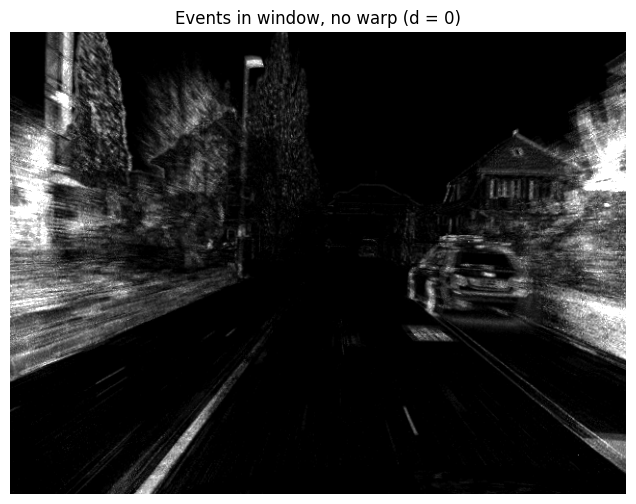

In [5]:
# full-frame IWE with d = 0 is just the unwarped, motion-blurred event image.
# Bilinear voting also avoids the moire/grid artifacts that integer rounding of rectified coords causes.
counts = iwe(x, y, tn, (0, 0), (H, W), sigma=0)
plt.figure(figsize=(8, 6)); plt.imshow(counts, cmap="gray", vmax=np.percentile(counts, 99))
plt.title("Events in window, no warp (d = 0)"); plt.axis("off"); plt.show()

## 5. Single patch: full contrast landscape

Exhaustive grid search over `d` for one 64×64 patch to see the shape of the objective. The canvas is padded so events warped past the patch edge aren't dropped. The patch location was chosen because it has both textured events and decent GT coverage.

The heatmap shows how peaked (or not) the objective is; an elongated peak means flow is poorly constrained along that axis (aperture problem, e.g. a patch dominated by edges of one orientation). The IWE panels are a zoomed crop of just this patch (dashed box = patch, the dark border is the padding), blurred with `sigma=1`, which is why they look different from the full-frame image. The leftmost panel shows where the patch sits. Comparing d = 0 to the best d shows the blurred vs. sharpened edges. The GT median is only a rough reference since true flow varies within the patch (forward driving gives a diverging field).

9,275 events, 3721 evaluations in 4.0s
CMax flow: [8. 4.]   GT median in patch: [11.6  5.6]


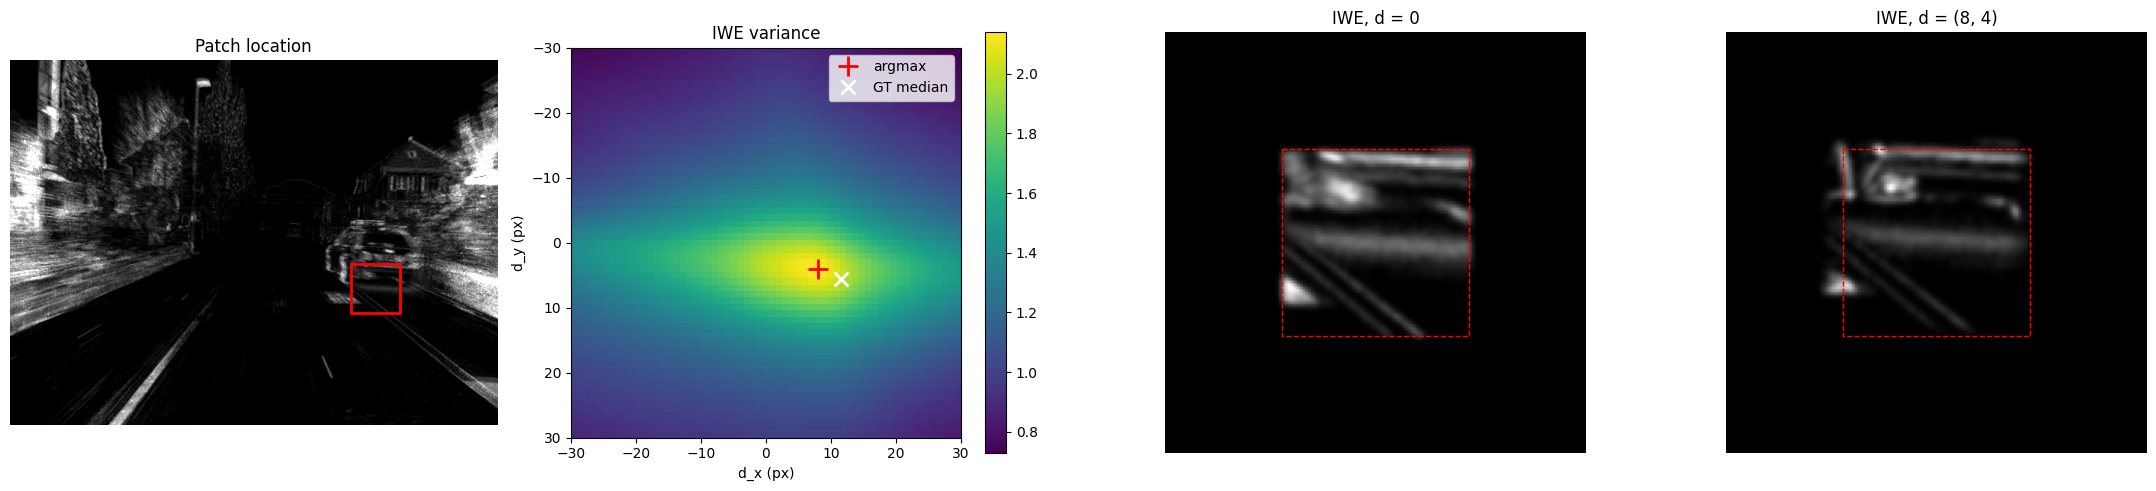

In [6]:
cx, cy, ps, pad = 480, 300, 64, 40
x0, y0, x1, y1 = cx - ps // 2, cy - ps // 2, cx + ps // 2, cy + ps // 2
m = (x >= x0) & (x < x1) & (y >= y0) & (y < y1)
org, shp = (x0 - pad, y0 - pad), (ps + 2 * pad, ps + 2 * pad)

grid = np.arange(-30, 31, 1.0)
tic = time.time()
S = np.array([[contrast(iwe(x[m], y[m], tn[m], (dx, dy), shp, org)) for dx in grid] for dy in grid])
iy, ix = np.unravel_index(S.argmax(), S.shape)
d_best = np.array([grid[ix], grid[iy]])
gt_med = np.median(gt[y0:y1, x0:x1][valid[y0:y1, x0:x1]], axis=0)
print(f"{m.sum():,} events, {len(grid)**2} evaluations in {time.time() - tic:.1f}s")
print(f"CMax flow: {d_best}   GT median in patch: {gt_med.round(1)}")

fig, ax = plt.subplots(1, 4, figsize=(22, 4.8))
ax[0].imshow(counts, cmap="gray", vmax=np.percentile(counts, 99))
ax[0].add_patch(plt.Rectangle((x0, y0), ps, ps, fill=False, ec="red", lw=2))
ax[0].set_title("Patch location"); ax[0].axis("off")
ax = ax[1:]
im = ax[0].imshow(S, extent=[grid[0], grid[-1], grid[-1], grid[0]], cmap="viridis")
ax[0].plot(*d_best, "r+", ms=14, mew=2, label="argmax")
ax[0].plot(*gt_med, "wx", ms=10, mew=2, label="GT median")
ax[0].set_xlabel("d_x (px)"); ax[0].set_ylabel("d_y (px)"); ax[0].set_title("IWE variance"); ax[0].legend()
plt.colorbar(im, ax=ax[0])
for a, d, title in ((ax[1], (0, 0), "IWE, d = 0"), (ax[2], d_best, f"IWE, d = ({d_best[0]:.0f}, {d_best[1]:.0f})")):
    a.imshow(iwe(x[m], y[m], tn[m], d, shp, org), cmap="gray"); a.set_title(title); a.axis("off")
    a.add_patch(plt.Rectangle((pad - 0.5, pad - 0.5), ps, ps, fill=False, ec="red", lw=1, ls="--"))
plt.tight_layout(); plt.show()

## 6. Patch-wise flow over the full frame

Same objective, applied independently to a grid of 64×64 patches (`patchwise_flow` in `evcam/cmax.py`, which calls `cmax_patch` on each patch). Full grid search per patch is too slow, so this uses a coarse-to-fine search: step 4 px over ±40, then step 1 px around the best coarse point. Patches with too few events are skipped (left as NaN).

Patch size is the main tradeoff. Larger patches have more events and a better-conditioned objective, but the constant-flow assumption breaks down more.

In [7]:
PS, MIN_EVENTS = 64, 500
tic = time.time()
est = patchwise_flow(x, y, tn, (H, W), patch_size=PS, min_events=MIN_EVENTS)   # (H, W, 2), NaN in skipped patches
print(f"done in {time.time() - tic:.0f}s")

done in 16s


## 6b. Before vs. after motion compensation (full frame)

Each event is warped with the flow of the patch it came from (events in skipped patches are left unwarped), then accumulated into one full-frame IWE. Left is the d = 0 image from section 4, right is the compensated one, both with no blur and the same display scaling. If the per-patch flows are right, edges should collapse into thin lines. Tile seams and residual blur show where constant flow per patch doesn't hold.

full-frame contrast: before 36.666   after 60.980


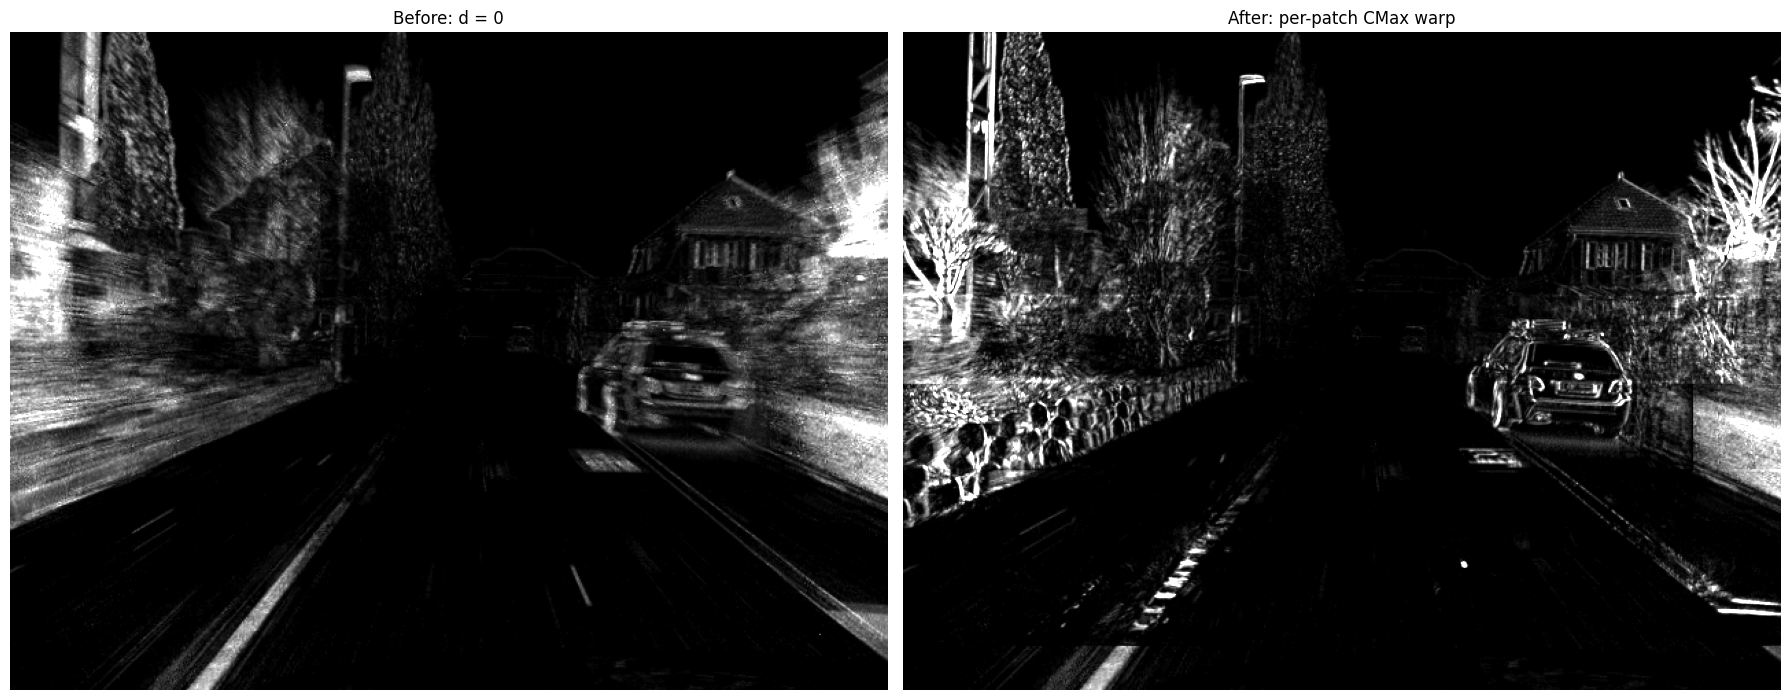

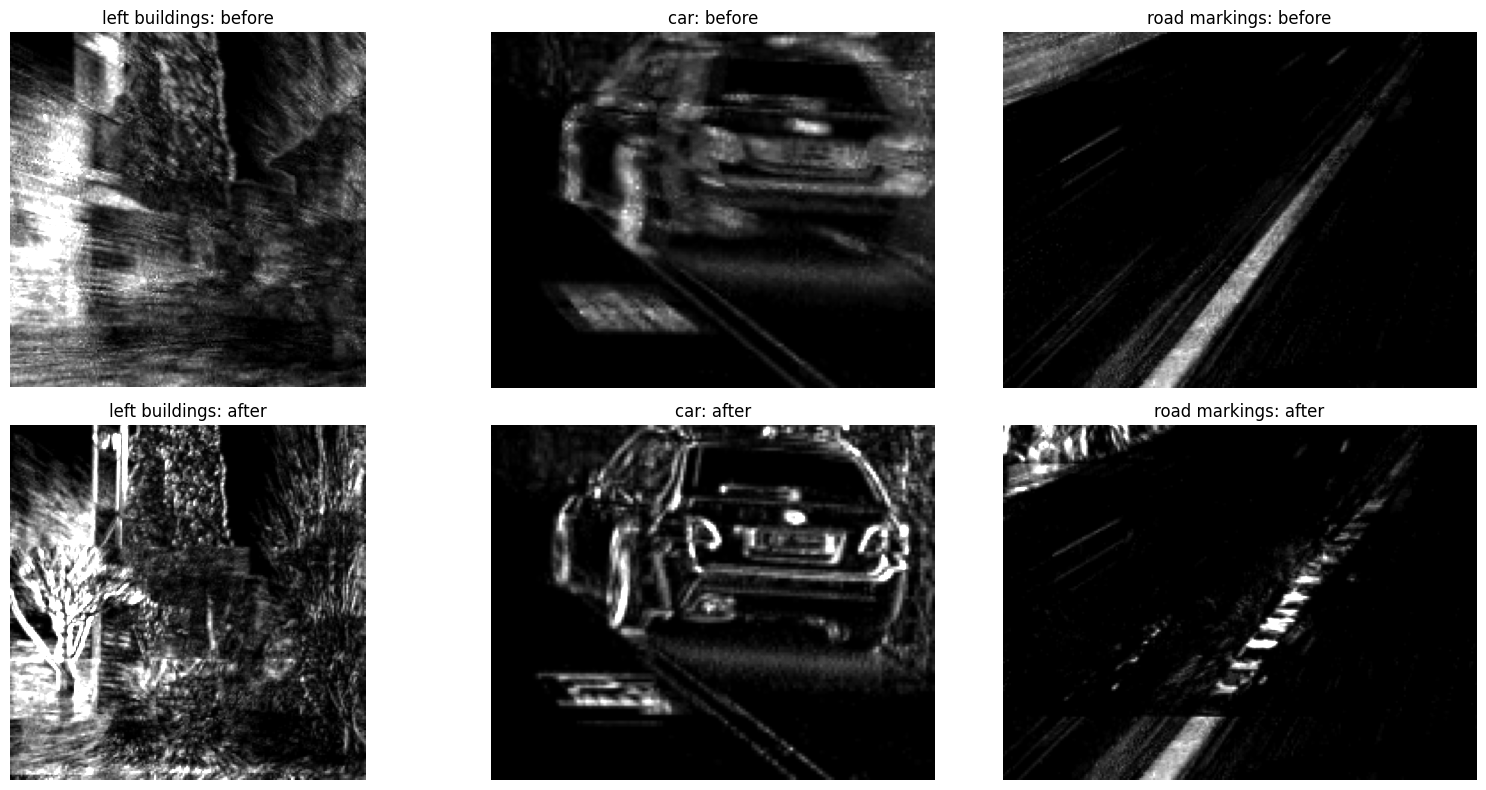

In [8]:
# per-event flow lookup from the patch-wise estimate
xi = np.clip(np.round(x).astype(int), 0, W - 1)
yi = np.clip(np.round(y).astype(int), 0, H - 1)
d_ev = np.nan_to_num(est[yi, xi])                     # (N, 2); NaN patches -> no warp
comp = iwe(x, y, tn, (d_ev[:, 0], d_ev[:, 1]), (H, W), sigma=0)
print(f"full-frame contrast: before {contrast(counts):.3f}   after {contrast(comp):.3f}")

vmax = np.percentile(counts, 99)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ax[0].imshow(counts, cmap="gray", vmax=vmax); ax[0].set_title("Before: d = 0")
ax[1].imshow(comp, cmap="gray", vmax=vmax); ax[1].set_title("After: per-patch CMax warp")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

# zoomed crops (y0, y1, x0, x1) to make the sharpening visible
crops = {"left buildings": (60, 260, 0, 200), "car": (220, 340, 390, 540), "road markings": (300, 480, 60, 300)}
fig, ax = plt.subplots(2, len(crops), figsize=(16, 8))
for j, (name, (r0, r1, c0, c1)) in enumerate(crops.items()):
    ax[0, j].imshow(counts[r0:r1, c0:c1], cmap="gray", vmax=vmax); ax[0, j].set_title(f"{name}: before")
    ax[1, j].imshow(comp[r0:r1, c0:c1], cmap="gray", vmax=vmax); ax[1, j].set_title(f"{name}: after")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

## 7. Evaluation against GT

DSEC-Flow metrics on pixels where GT is valid and a patch estimate exists: EPE (mean endpoint error, px) and 3PE (% of pixels with error > 3 px). Zero flow is included as a sanity baseline. The metric functions are in `evcam/metrics.py`.

Note this isn't directly comparable to the benchmark leaderboard, which uses the test set and dense per-pixel predictions.

coverage: 85.3% of GT pixels
CMax      EPE 4.06 px   3PE 37.4%
zero flow EPE 10.35 px   3PE 81.5%


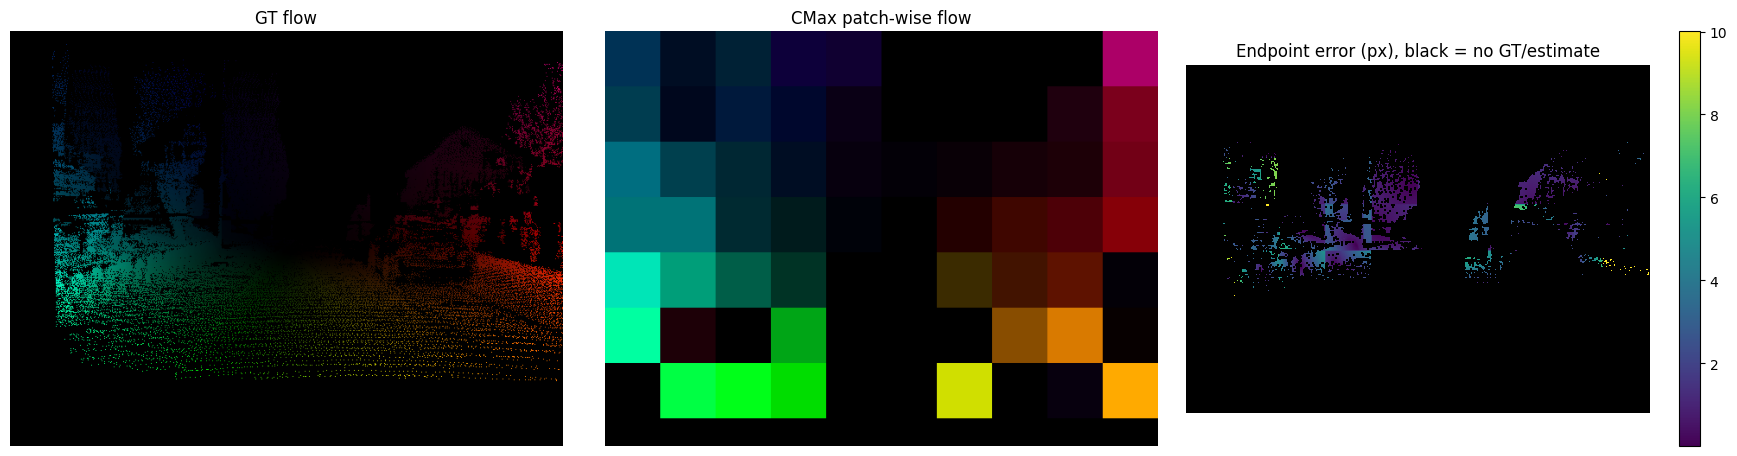

In [9]:
ok = valid & ~np.isnan(est[..., 0])
err = endpoint_error(est, gt)          # (H, W) per-pixel error, used for the error map below
zero = np.zeros_like(gt)
print(f"coverage: {ok.sum() / valid.sum():.1%} of GT pixels")
print(f"CMax      EPE {epe(est, gt, ok):.2f} px   3PE {n_pixel_error(est, gt, ok, n=3):.1%}")
print(f"zero flow EPE {epe(zero, gt, ok):.2f} px   3PE {n_pixel_error(zero, gt, ok, n=3):.1%}")

mx = np.nanpercentile(np.linalg.norm(gt[valid], axis=-1), 99)
est_rgb = flow_to_rgb(np.nan_to_num(est), ~np.isnan(est[..., 0]), mx)
err_img = np.where(ok, err, np.nan)
err_cmap = plt.get_cmap("viridis").copy(); err_cmap.set_bad("black")

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].imshow(flow_to_rgb(gt, valid, mx)); ax[0].set_title("GT flow")
ax[1].imshow(est_rgb); ax[1].set_title("CMax patch-wise flow")
im = ax[2].imshow(err_img, cmap=err_cmap, vmax=10); ax[2].set_title("Endpoint error (px), black = no GT/estimate")
plt.colorbar(im, ax=ax[2])
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

Arrows over the no-warp event image, one per patch: GT patch median (thick cyan) and CMax (thin red, drawn on top). Scaled by `ARROW_SCALE` for visibility. Makes direction errors easier to spot than the color maps.

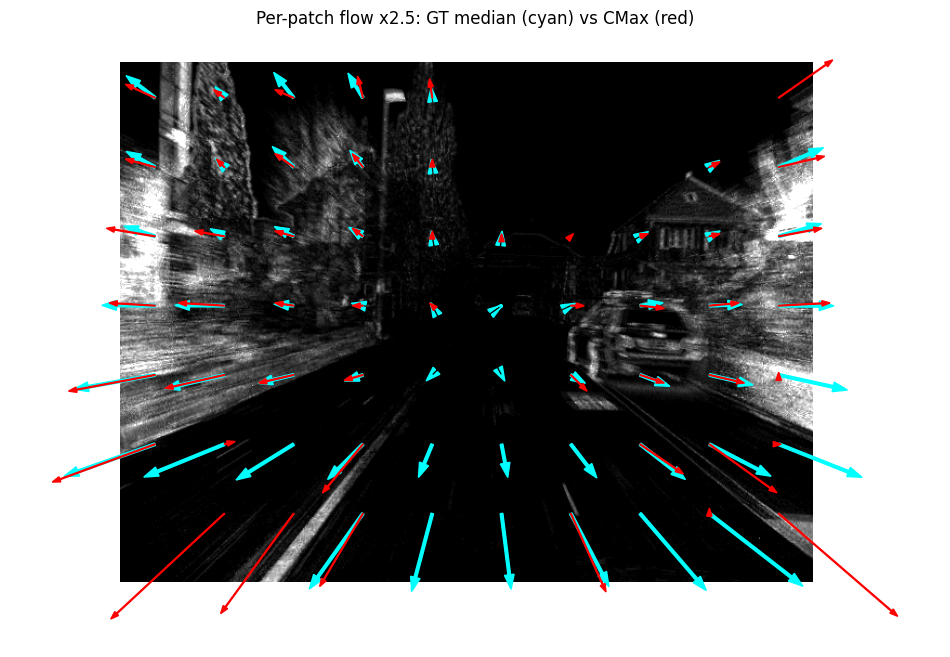

In [10]:
ARROW_SCALE = 2.5
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(counts, cmap="gray", vmax=np.percentile(counts, 99))
for py in range(0, H - PS + 1, PS):
    for px in range(0, W - PS + 1, PS):
        c = (px + PS / 2, py + PS / 2)
        v = valid[py:py + PS, px:px + PS]
        if v.sum() > 50:
            g = np.median(gt[py:py + PS, px:px + PS][v], axis=0) * ARROW_SCALE
            ax.arrow(*c, *g, color="cyan", width=2.5, head_width=9, length_includes_head=True)
        d = est[py + PS // 2, px + PS // 2]
        if not np.isnan(d[0]):
            ax.arrow(*c, *(d * ARROW_SCALE), color="red", width=0.8, head_width=5, length_includes_head=True)
ax.set_title(f"Per-patch flow x{ARROW_SCALE}: GT median (cyan) vs CMax (red)"); ax.axis("off")
plt.show()

## 8. Notes and next steps

- Constant flow per patch is a big limitation. Forward driving creates a diverging field, so the assumption is worst in patches with large depth changes and near the image edges, where flow is largest.
- Low-texture patches (e.g. road with only lane markings) give weakly constrained objectives.
- Current knobs: patch size, window length (fixed at 100 ms here to match GT), blur `sigma`, and search range.
- Possible extensions: other objectives (e.g. sum of squares, gradient magnitude), gradient-based optimization instead of grid search, richer motion models (affine, rotation), multi-scale patches, and the Shiba et al. 2022 improvements on this same dataset.
- For comparison: the local plane-fitting method (Benosman et al. 2014) on the same window.